# GLCM

In [ ]:
import numpy as np
import cv2
import networkx as nx
from skimage.feature import local_binary_pattern
from google.colab.patches import cv2_imshow
from skimage.feature import graycomatrix, graycoprops
import numpy as np

In [ ]:
# dilate mask and get inner and outer boundary of contour
def get_coord(mask, iterations):

  kernel = np.ones((3,3), np.uint8)

  # find dilated image
  dilated = cv2.dilate(mask, kernel, iterations=iterations)
  # cv2_imshow(dilated)

  # find the boundaries
  eroded= cv2.erode(dilated, kernel, iterations=1)
  final= dilated-eroded
  # cv2_imshow(final)

  contours, hierarchy = cv2.findContours(final.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
  # contours = contours[::-1]
  # hierarchy = hierarchy[::-1]

  # find inner and outer contours
  outer_contours = []
  inner_contours = []

  outer=[]
  inner=[]

  mx=-1
  for i in hierarchy[0]:
    mx= max(mx, i[3])

  for i, contour in enumerate(contours):
    #print(hierarchy[0][i][3])
    # Check the hierarchy to classify contours
    if hierarchy[0][i][3] == -1 and len(outer)==0:  # Outer contour (no parent)
      outer_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        outer.append([y,x])
    elif hierarchy[0][i][3] == mx:  # Inner contour (has a parent)
      inner_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        inner.append([y,x])

  # output_image = np.zeros_like(mask)
  # for p in outer:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)
  # for p in inner:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)

  # find all points which are white
  white = np.column_stack(np.where(dilated == 255)).tolist()

  for i in outer:
    i[0]= int(i[0])
    i[1]= int(i[1])
  for i in inner:
    i[0]= int(i[0])
    i[1]= int(i[1])

  return white, outer, inner


In [ ]:
def similarity_function(p, q, gabor_p, gabor_q, sigma_I=10, sigma_G=5, sigma_d=2):
    """Compute similarity weight between two pixels using intensity and Gabor features."""
    # intensity_diff = np.linalg.norm(np.array(p) - np.array(q))
    gabor_diff =np.linalg.norm(np.array(gabor_p) - np.array(gabor_q))
    spatial_diff = 1
    weight = 1 / (1 + abs(int(gabor_p) - int(gabor_q)))
    spatial_diff = 1
    return weight
    return (
        # np.exp(- (intensity_diff ** 2) / (2 * sigma_I ** 2)) *
        np.exp(- (gabor_diff ** 2) / (2 * sigma_G ** 2)) *
        np.exp(- (spatial_diff ** 2) / (2 * sigma_d ** 2))
    )


# create custom weight function
def get_weight(img, gabor_features, lst1, lst2):
    """Computes edge weight based on intensity and Gabor texture features."""
    return similarity_function(img[lst1[0], lst1[1]], img[lst2[0], lst2[1]],
                               gabor_features[lst1[0], lst1[1]], gabor_features[lst2[0], lst2[1]])


def get_graph(img, node_map, gabor_features):
  G = nx.Graph()

  # Define 8-connectivity for neighboring pixels
  for x in range(height):
    for y in range(width):

      if node_map.get(str([x,y])) == None:
        continue

      if x < height - 1: # down node
        next= [x+1,y]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features ,[x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

      if y < width - 1: # right node
        next= [x,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x < height - 1 and y < width -1 : # down-right node
        next= [x+1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x > 0 and y < width-1: # top-right node
        next= [x-1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,gabor_features, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

# See graph adjacency list
# G.adj
  return G


In [ ]:
def get_cut(G):
  cut_value, partition = nx.minimum_cut(G, "source", "sink")
  reachable, non_reachable = partition
  cutset = set()
  for u, nbrs in ((n, G[n]) for n in reachable):
    cutset.update((u, v) for v in nbrs if v in non_reachable)

  return cutset


In [ ]:
def nearest_source(a, node_map):
  dx= [-1, -1, -1, 0, 0, 1, 1, 1]
  dy= [-1, 0, 1, -1, 1, -1, 0, 1]
  for k in range(8):
    x= a[0]+ dx[k]
    y= a[1]+ dy[k]
    if node_map.get(str([x,y])) != None and node_map[str([x,y])]=="source":
      return (x,y)

  return None

def get_nextmask(cutset, node_map):
  contour_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
  next_mask = np.zeros_like(img)

  for [a,b] in cutset:
    if a == "source":
      x,y= nearest_source(b, node_map)
      next_mask[x,y]=255
      contour_image[x,y]= (0, 255, 0)
    else:
      next_mask[a[0], a[1]]=255
      contour_image[a[0],a[1]]= (0, 255, 0)

  return next_mask,contour_image


In [ ]:
def apply_gabor_filters(img, frequencies=[0.2,0.4], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    """Applies Gabor filters to an image and returns the response maps."""
    gabor_responses = np.zeros_like(img, dtype=np.float32)
    for theta in angles:
        for freq in frequencies:
            kernel = cv2.getGaborKernel((7, 7), 5, theta, freq * 10, 0.5, 0, ktype=cv2.CV_32F)
            filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
            gabor_responses += np.abs(filtered)
    return (gabor_responses - np.min(gabor_responses)) / (np.max(gabor_responses) - np.min(gabor_responses)) * 255


180 200


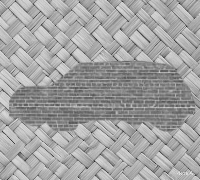

In [ ]:
# Load the image
img = cv2.imread('/content/car_texture.jpg', 0)  #load image in grayscale
img= cv2.resize(img, (200, 180))
(height,width)= img.shape
print(height, width)
cv2_imshow(img)


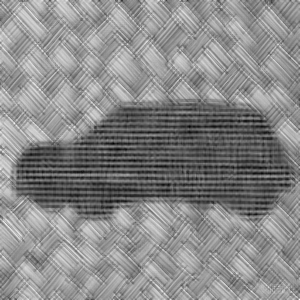

In [ ]:
gabor_features= apply_gabor_filters(img)
cv2_imshow(gabor_features)

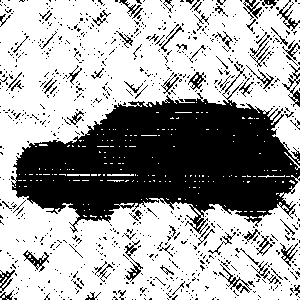

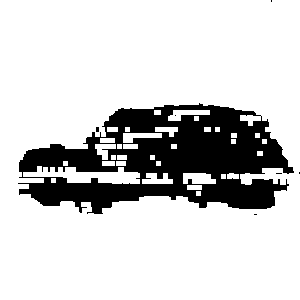

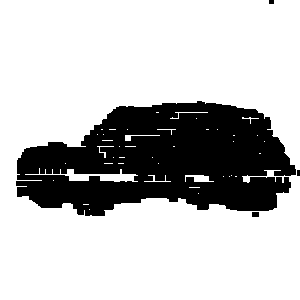

In [ ]:
p= gabor_features
_, binary_thresh = cv2.threshold(p,130, 255, cv2.THRESH_BINARY)
cv2_imshow(binary_thresh)
# Create kernel (structuring element)
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(binary_thresh, kernel, iterations=2)
cv2_imshow(dilated)
# Apply erosion
eroded = cv2.erode(dilated, kernel, iterations=2)

# Display
cv2_imshow(eroded)

gabor_features= eroded

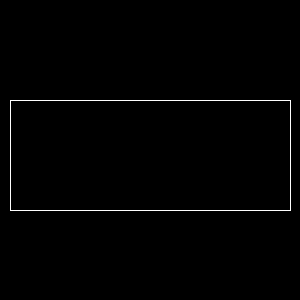

In [ ]:
# Initial binary mask (user-provided or from an edge detector)
mask = np.zeros_like(img)
#mushroom - cv2.circle(mask,(width//2, height//2),60, 255, 1)
mask= cv2.rectangle(mask, (10,100), (290,213), 255, 1)
cv2_imshow(mask)

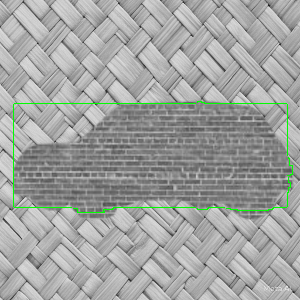

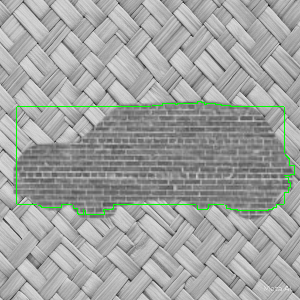

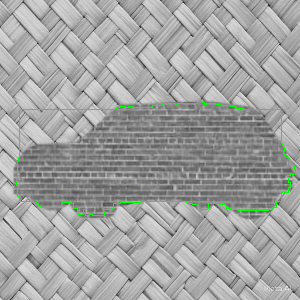

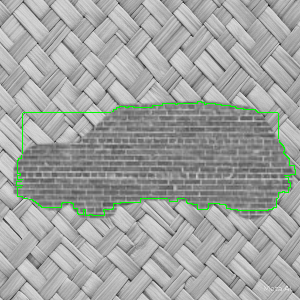

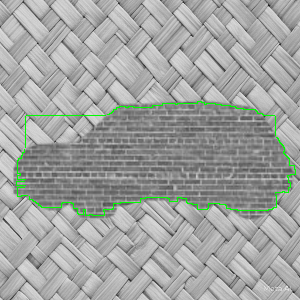

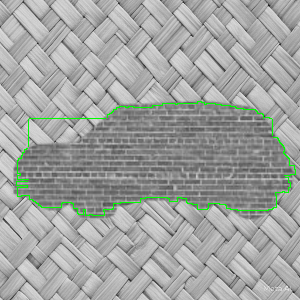

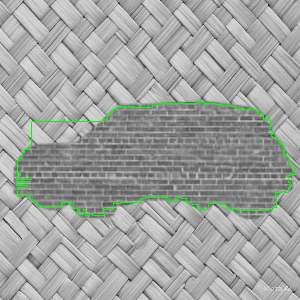

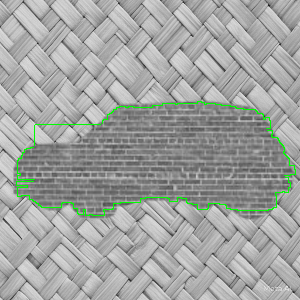

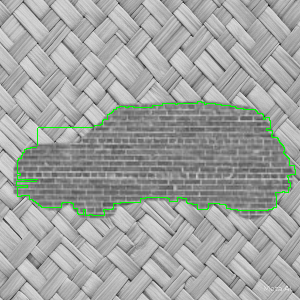

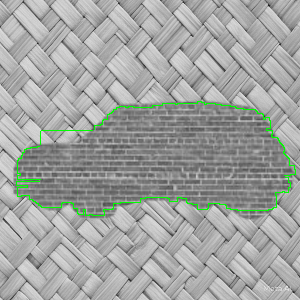

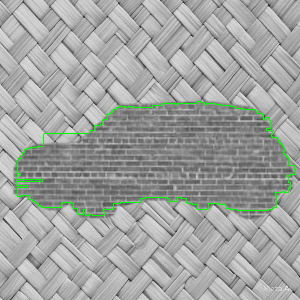

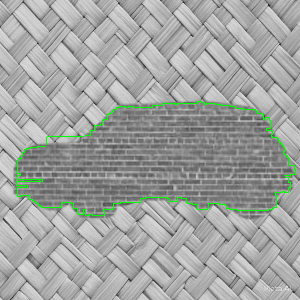

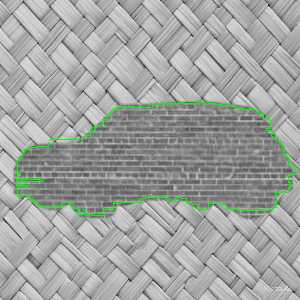

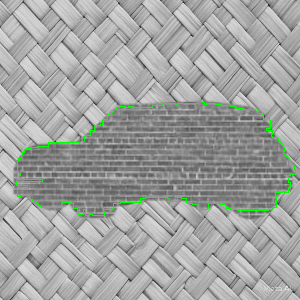

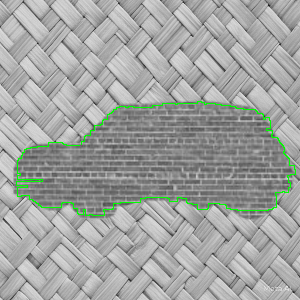

In [ ]:
for i in range(15):
  allnodes,sink,source= get_coord(mask, 3)
  node_map={}
  for node in allnodes:
    node_map[str(node)]= (node[0], node[1])

  for node in source:
    node_map[str(node)]= "source"

  for node in sink:
    node_map[str(node)]= "sink"

  G= get_graph(img, node_map, gabor_features)
  cutset= get_cut(G)
  mask,contour_image= get_nextmask(cutset, node_map)
  cv2_imshow(contour_image)

cv2.waitKey(0)
cv2.destroyAllWindows()